<a href="https://colab.research.google.com/github/Sathishs2004/CatVsDog_CNN_Classification/blob/main/cat_vs_dog_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [2]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

In [3]:
train_path="/content/drive/MyDrive/CNN_project/datasets/train"

test_path="/content/drive/MyDrive/CNN_project/datasets/test"

## Load Datasets

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen=ImageDataGenerator(
    rescale=1./255
)

In [5]:
training_set=train_datagen.flow_from_directory(

    train_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='binary'

)

Found 13 images belonging to 3 classes.


In [6]:
test_set=test_datagen.flow_from_directory(

    test_path,

    target_size=(128,128),

    batch_size=32,

    class_mode='binary'

)

Found 6 images belonging to 3 classes.


## Build CNN Model

In [7]:
cnn=Sequential()

## 1st convolutional layer

In [8]:
cnn.add(

Conv2D(

32,

(3,3),

activation='relu',

input_shape=(128,128,3)

)

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Max Pooling

In [9]:
cnn.add(

MaxPooling2D(

pool_size=(2,2)

)

)

## 2nd convolutional layer

In [10]:
cnn.add(

Conv2D(

64,

(3,3),

activation='relu'

)

)

## Max pooling

In [11]:
cnn.add(

MaxPooling2D(

pool_size=(2,2)

)

)

## 3rd convolutional layer

In [12]:
cnn.add(

Conv2D(

128,

(3,3),

activation='relu'

)

)

## Max pooling

In [13]:
cnn.add(

MaxPooling2D(

pool_size=(2,2)

)

)

## Flatten layer

In [14]:
cnn.add(

Flatten()

)

## Fully connected layer

In [15]:
cnn.add(

Dense(

128,

activation='relu'

)

)

In [16]:
cnn.add(

Dropout(

0.5

)

)

## Output layer

In [17]:
cnn.add(

Dense(

1,

activation='sigmoid'

)

)

## Model summary

In [18]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cnn.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']

)

## Train model

In [30]:
history=cnn.fit(

training_set,

validation_data=test_set,

epochs=100

)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4615 - loss: -3896.4756 - val_accuracy: 0.5000 - val_loss: -6689.5508
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4615 - loss: -4693.8159 - val_accuracy: 0.5000 - val_loss: -8837.1572
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: -6125.3052 - val_accuracy: 0.5000 - val_loss: -11562.6094
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: -8996.5645 - val_accuracy: 0.5000 - val_loss: -14960.9219
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: -11460.8184 - val_accuracy: 0.5000 - val_loss: -19188.1992
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: -15079.8457 - val_accuracy: 0.5000 - val_loss: -24405.1348
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 - loss: -17912.0137 - val_accuracy: 0.5000 - val_loss: -30816.4844
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4615 -

In [32]:
cnn.save("model.h5")

## Accuracy

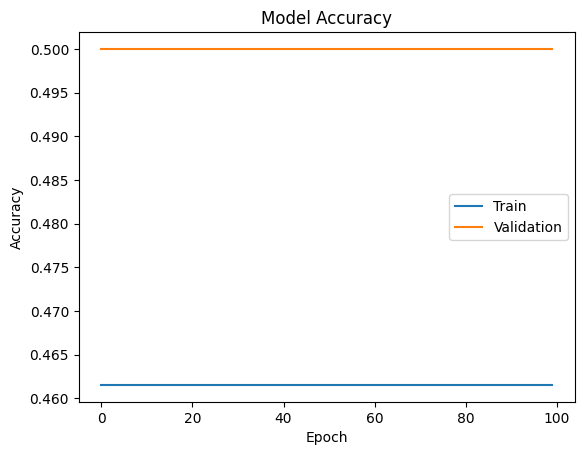

In [33]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

## Loss

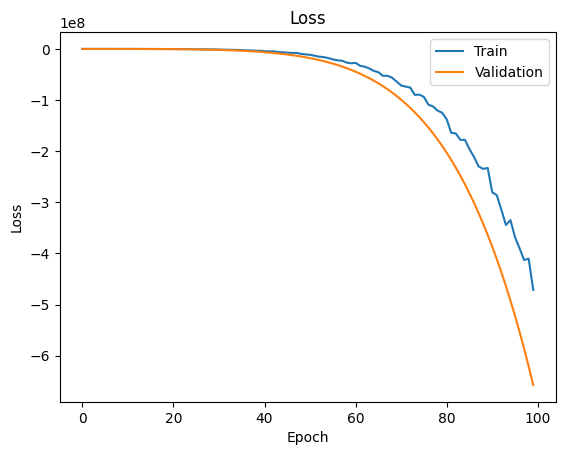

In [34]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

## Predict New Image

In [40]:
import numpy as np

from tensorflow.keras.preprocessing import image

test_image=image.load_img(
'/content/drive/MyDrive/CNN_project/datasets/train/dog/pexels-gustavodenuncio-26607800.jpg'
,

target_size=(128,128)

)

test_image=image.img_to_array(test_image)

test_image=np.expand_dims(test_image,axis=0)

result=cnn.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


## Predicition

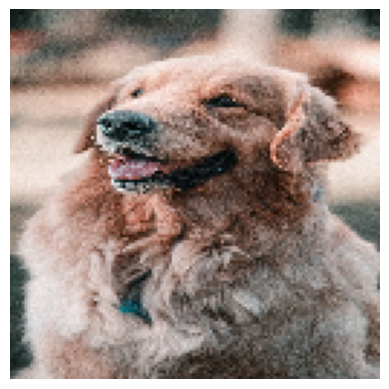

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction Value: 1.0
🐶 Prediction: Dog


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Load image
img = image.load_img('/content/drive/MyDrive/CNN_project/datasets/train/dog/pexels-gustavodenuncio-26607800.jpg', target_size=(128,128))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Prepare image
test_image = image.img_to_array(img)
test_image = test_image / 255.0
test_image = np.expand_dims(test_image, axis=0)

# Predict
result = cnn.predict(test_image)

print("Prediction Value:", result[0][0])

if result[0][0] > 0.5:
    print("🐶 Prediction: Dog")
else:
    print("🐱 Prediction: Cat")

## Evaluate Model

In [38]:
loss,accuracy=cnn.evaluate(test_set)

print("Loss :",loss)

print("Accuracy :",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - accuracy: 0.5000 - loss: -657168960.0000
Loss : -657168960.0
Accuracy : 0.5
